In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch

from brain_image.model.comm.comm import CoMM
from brain_image.model.comm.encoders import AlexNetEncoder
from brain_image.model.comm.input_adapters import FeaturesInputAdapter, PatchedInputAdapter
from brain_image.model.comm.mmfusion import MMFusion
from brain_image.model.eeg_encoder.atms import AtmsEEGEncoder, AtmsEEGEncoderConfig
from brain_image.model.img_encoder import CLIPImageEncoder

from torch.utils.data import DataLoader
from pathlib import Path

from brain_image.data.things_eeg2_dataset import ThingsEEG2Dataset, ThingsEEG2DatasetConfig


/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadat

In [3]:
things_path = Path("data/things-eeg2")
dataset_config = ThingsEEG2DatasetConfig(subs=[1], num_workers=0)
dataset = ThingsEEG2Dataset(
    dataset_config, 
    split="test", 
)
loader = DataLoader(dataset, batch_size=4, num_workers=0)

In [4]:
from brain_image.data.data import batch_load_images, load_image_from_path


ex_batch = next(iter(loader))
img = batch_load_images(ex_batch["img_path"])
eeg = ex_batch["eeg_data"]

img = img.to(device="cuda")
eeg = eeg.to(device="cuda", dtype=float)

...;

In [5]:
from brain_image.augment import EEGAugmentationPipeline, ImageAugmentationPipeline


In [6]:
I = torch.arange(eeg.size(2)).repeat(3, 1)
I.shape

torch.Size([3, 250])

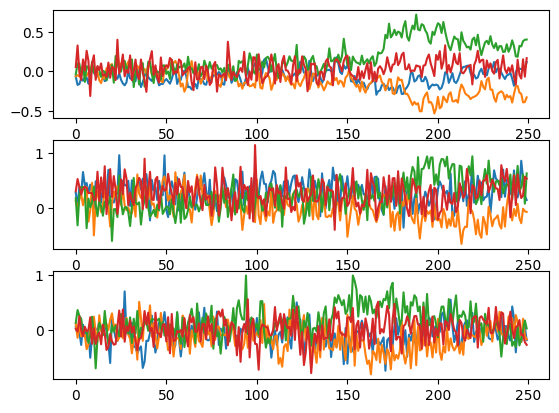

In [7]:
import matplotlib.pyplot as plt
import numpy as np


eeg_augmenter = EEGAugmentationPipeline()
eeg_augmenter.eval()

with torch.no_grad():
    eeg_aug1 = eeg_augmenter(eeg)
    eeg_aug2 = eeg_augmenter(eeg)
C = 4
nC = 4
S = 0
I = torch.arange(eeg.size(2)).repeat(nC, 1)


plt.subplot(3, 1, 1)
plt.plot(I.T, eeg[S, C:C+nC].T.detach().cpu().numpy())
plt.subplot(3, 1, 2)
plt.plot(I.T,  eeg_aug1[S, C:C+nC].T.detach().cpu().numpy())
plt.subplot(3, 1, 3)
plt.plot(I.T,  eeg_aug2[S, C:C+nC].T.detach().cpu().numpy())
...;

tensor(0.9990, device='cuda:0')


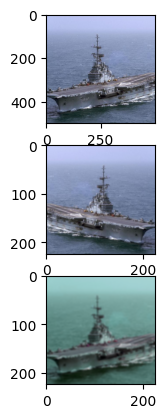

In [8]:
import matplotlib.pyplot as plt 

image_augmenter = ImageAugmentationPipeline()
image_augmenter.eval()
from torchvision.transforms import v2 as tv2

img2 = tv2.Compose([
    tv2.Resize(224, interpolation=tv2.InterpolationMode.BICUBIC),
    tv2.ToDtype(torch.float32, scale=True)
])(img)

with torch.no_grad():
    img_aug1 = image_augmenter(img2)
    img_aug2 = image_augmenter(img2)

print(img_aug1.max())

plt.subplot(3, 1, 1)
plt.imshow((img[0] / 255.).permute(1, 2, 0).detach().cpu().numpy())
plt.subplot(3, 1, 2)
plt.imshow(img_aug1[0].permute(1, 2, 0).detach().cpu().numpy())
plt.subplot(3, 1, 3)
plt.imshow(img_aug2[0].permute(1, 2, 0).detach().cpu().numpy())



In [9]:
from brain_image.data.data import EEGDataModule, EEGDatasetConfig

data_config = ThingsEEG2DatasetConfig(data_path=Path("data/things-eeg2"), subs=[8], num_workers=0, batch_size=32)
data_module = EEGDataModule(data_config)


In [ ]:
import logging
from pytorch_lightning import LightningModule


from torchvision.transforms import v2 as tv2
import itertools as it

import tqdm

from brain_image.model.comm.comm_loss import CoMMLoss


class CommTrainModule(LightningModule):
    def __init__(self, comm: CoMM, data_module: EEGDataModule, preload_images: bool = True, cache_images: bool = True):
        super().__init__()

        # TODO: Refactor out encoders from CoMM module
        self.comm = comm
        self.data_module = data_module

        self.image_augmenter = ImageAugmentationPipeline()
        self.eeg_augmenter = EEGAugmentationPipeline()
        self.image_augmenter.requires_grad_(False)
        self.eeg_augmenter.requires_grad_(False)

        self.image_pipe = tv2.Compose(
            [
                tv2.Resize((224), interpolation=tv2.InterpolationMode.BICUBIC),
                tv2.ToDtype(torch.float32, scale=True),
            ]
        )

        self.comm_loss = CoMMLoss()
        self.images = {}

        self.cache_images = cache_images
        self.preload_images = preload_images 

        if preload_images:
            for split in ["train", "val", "test"]:
                dataset = data_module.get_dataset(split)
                img_paths = dataset.get_image_paths()
                
                for i in tqdm.tqdm(range(0, len(img_paths), 32), desc=f"Preloading {split} images"):
                    img_batch = img_paths[i:i+32]
                    self.get_images(img_batch)
        

    def get_images(self, image_paths: list[Path]) -> torch.Tensor:
        if self.cache_images and all(path in self.images for path in image_paths):
            return torch.stack([self.images[path] for path in image_paths])
        
        images = batch_load_images(image_paths, parallel=self.preload_images)
        images = self.image_pipe(images)

        if self.cache_images:
            for path, image in zip(image_paths, images):
                self.images[path] = image

        return images


    def train_dataloader(self):
        return self.data_module.train_dataloader()

    def val_dataloader(self):
        return self.data_module.val_dataloader()

    def test_dataloader(self):
        return self.data_module.test_dataloader()

    @torch.no_grad()
    def prepare_batch(self, batch):
        device = self.device

        eeg = batch["eeg_data"].to(device)
        img_paths = batch["img_path"]

        imgs = self.get_images(img_paths)

        img_aug1 = self.image_augmenter(imgs)
        img_aug2 = self.image_augmenter(imgs)
        eeg_aug1 = self.eeg_augmenter(eeg)
        eeg_aug2 = self.eeg_augmenter(eeg)

        return {
            "eeg": eeg,
            "img": imgs,
            "eeg_aug1": eeg_aug1,
            "eeg_aug2": eeg_aug2,
            "img_aug1": img_aug1,
            "img_aug2": img_aug2,
        }

    def comm_forward(self, eeg_aug1, eeg_aug2, img_aug1, img_aug2):
        """
        Outputs:
        - aug1_embed:
              <batch_size, n_modalities, embed_dim>
              Multimodal embedding of the first augmentation
        - aug2_embed:
              <batch_size, n_modalities, embed_dim>
              Multimodal embedding of the second augmentation
        - prototype:
              <int>
              Index of the multimodal representation within the batch.
              The modality at index `prototype` will be contrasted against all others.
        """
        output_dict = self.comm.forward([img_aug1, eeg_aug1], [img_aug2, eeg_aug2])
        return output_dict

    def forward(self, batch):
        eeg_aug1 = batch["eeg_aug1"]
        eeg_aug2 = batch["eeg_aug2"]
        img_aug1 = batch["img_aug1"]
        img_aug2 = batch["img_aug2"]

        comm_out = self.comm_forward(eeg_aug1, eeg_aug2, img_aug1, img_aug2)
        loss_dict = self.comm_loss(comm_out)

        return comm_out, loss_dict

    def training_step(self, batch, *args, **kwargs):
        batch = self.prepare_batch(batch)

        _, loss_dict = self.forward(batch)

        self.log("train_loss", loss_dict["loss"], prog_bar=True)
        return loss_dict
    
    def validation_step(self, batch, *args, **kwargs):
        batch = self.prepare_batch(batch)

        with torch.no_grad():
            comm_out, loss_dict = self.forward(batch)
        
        z1 = comm_out["aug1_embed"]
        z2 = comm_out["aug2_embed"]
        ssl_acc = self.get_ssl_accuracy(z1, z2)

        self.log("val_loss", loss_dict["loss"], prog_bar=True)
        self.log("val_acc", ssl_acc, prog_bar=True)
        return loss_dict
    
    def test_step(self, batch, *args, **kwargs):
        batch = self.prepare_batch(batch)

        with torch.no_grad():
            comm_out, loss_dict = self.forward(batch)
        
        z1 = comm_out["aug1_embed"]
        z2 = comm_out["aug2_embed"]
        ssl_acc = self.get_ssl_accuracy(z1, z2)

        self.log("test_loss", loss_dict["loss"], prog_bar=True)
        self.log("test_acc", ssl_acc, prog_bar=True)
        return loss_dict


    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            it.chain(self.comm.parameters(), [self.comm_loss.temperature]),
            lr=3e-4,
            weight_decay=1e-4,
        )
        return optimizer

    @torch.no_grad()
    def get_ssl_accuracy(self, z1, z2, *args, **kwargs):
        sim = (z1 @ z2.T)  # dim [N, N] => the diag contains the correct pairs (i,j)

        pred = torch.argmax(sim, dim=1)
        accuracy = pred.eq(torch.arange(z1.size(0), device=z1.device)).mean()

        return accuracy

img_encoder = CLIPImageEncoder()
img_encoder.requires_grad_(False)
comm = CoMM(
    encoder=MMFusion(
        encoders=[  # Symmetric visual encoders
            # AlexNetEncoder(latent_dim=512, global_pool=""),
            img_encoder,  # 1024
            AtmsEEGEncoder(AtmsEEGEncoderConfig(d_channels=63, d_output=768)),
        ],
        input_adapters=[  # Pach adapters for multimodal fusion
            FeaturesInputAdapter(768, 512),
            # PatchedInputAdapter(num_channels=256, stride_level=1, patch_size_full=1, dim_tokens=512, image_size=6),
            # PatchedInputAdapter(num_channels=256, stride_level=1, patch_size_full=1, dim_tokens=512, image_size=6)
            FeaturesInputAdapter(768, 512),
        ],
        embed_dim=512,
    ),
    projection=CoMM._build_mlp(512, 512, 256),
    optim_kwargs=dict(lr=3e-4, weight_decay=1e-4),
    loss_kwargs=dict(temperature=0.1),
)
comm = comm.float().to("cuda")
comm_module = CommTrainModule(comm=comm, data_module=data_module)

Preloading test images: 100%|██████████| 7/7 [00:00<00:00, 565.92it/s]


In [11]:
import pytorch_lightning as pl
trainer = pl.Trainer(max_epochs=100)



INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [12]:
trainer.fit(comm_module)

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
INFO: You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Core

Training: |          | 0/? [00:00<?, ?it/s]

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
INFO:lightning.pytorch.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
